In [3]:
import torch
from torch import nn
import numpy as np
from environments.EMS_env import DiscreteEMSEnv, ContinousEMSEnv, drawndown, NormalizedEnv
env = DiscreteEMSEnv()
from matplotlib import pyplot as plt
from RL_algorithms.DQN import DDQN
from utils_functions.EMS_networks import LSTM_Q_Network

In [74]:
class ReplayMemory(object):
    """
    Replay memory class for storing transitions
    """

    def __init__(self, capacity, obs_dim, action_dim, device):
        self.states = torch.zeros(capacity, obs_dim).to(device)
        self.actions = torch.zeros(capacity, action_dim).to(device)
        self.next_states = torch.zeros(capacity, obs_dim).to(device)
        self.rewards = torch.zeros(capacity, 1).to(device)
        self.dones = torch.zeros(capacity, 1).to(device)
        self.idx:int = 0
        self.isFull = False
        self.capacity = capacity
        self.action_dim = action_dim
        self.device = device
        self.obs_dim = obs_dim

    def push(self, *args):
        """Save a transition"""
        self.states[self.idx] = args[0]
        self.actions[self.idx] = args[1]
        self.next_states[self.idx] = args[2]
        self.rewards[self.idx] = args[3]
        self.dones[self.idx] = args[4]
        self.idx = (self.idx + 1) % self.capacity
        if self.idx == 0:
            self.isFull = True

    def sample(self, batch_size, lookback=6):
        """Sample a batch of transitions"""
        if self.isFull:
            indices = np.random.randint(0, len, batch_size)
        else:
            indices = np.random.randint(0, self.idx, batch_size)

        states = []
        next_states = []
        actions = torch.zeros(batch_size, self.action_dim)
        rewards = torch.zeros(batch_size, 1)
        dones = torch.zeros(batch_size, 1)

        lengths = []
        
        for j, i in enumerate(indices):
            if i < self.idx:
                if i >= lookback:
                    states.append(self.states[i-lookback:i, :])
                    next_states.append(self.next_states[i-lookback:i, :])
                    lengths.append(lookback)
                else:
                    states.append(self.states[0:i, :])
                    next_states.append(self.next_states[0:i, :])
                    lengths.append(i)
            elif i - self.idx < lookback:
                states.append(self.states[self.idx:i, :])
                next_states.append(self.next_states[self.idx:i, :])
                lengths.append(i - self.idx)
            else:
                states.append(self.states[i-lookback:i, :])
                next_states.append(self.next_states[i-lookback:i, :])  
                lengths.append(lookback)  

            actions[j, :] = self.actions[i, :]
            rewards[j, 0] = self.rewards[i]
            dones[j, 0] = self.dones[i]        

        packed_states = torch.nn.utils.rnn.pad_sequence(states, batch_first=True)  
        packed_next_states = torch.nn.utils.rnn.pad_sequence(next_states, batch_first=True)
        
        p_s = torch.nn.utils.rnn.pack_padded_sequence(packed_states, lengths, batch_first=True, enforce_sorted=False)
        p_ns = torch.nn.utils.rnn.pack_padded_sequence(packed_next_states, lengths, batch_first=True, enforce_sorted=False)
            
        return p_s, actions, p_ns, rewards, dones

    def __len__(self):
        return len(self.memory)

In [118]:
rm = ReplayMemory(1000, 5, 3, 'cpu')
for i in range(100):
    rm.push(torch.tensor([1+i, 2+i, 3+i, 4+i, 5+i]), torch.tensor([i+1, i+2, i+3]), torch.tensor([2+i, 3+i, 4+i, 5+i, 6+i]), torch.tensor([1]), torch.tensor([0]))

s, a, ns, r, d = rm.sample(0)
    

RuntimeError: received an empty list of sequences

In [117]:
# test for replay buffer 
for i in range(50):
    s, a, ns, r, d = rm.sample(10)

    unpacked_s, _ = torch.nn.utils.rnn.pad_packed_sequence(s, batch_first=True) 
    unpacked_s_n , _ = torch.nn.utils.rnn.pad_packed_sequence(ns, batch_first=True)

    res = torch.sum(unpacked_s[:,1:, :] == unpacked_s_n[:, :-1, :])
    if res != 250:
        print('Error')
        break
 



RuntimeError: Length of all samples has to be greater than 0, but found an element in 'lengths' that is <= 0

In [94]:
class LSTM_Q_Network(nn.Module):
    """ Q network with LSTM structure. This network is used to learn the Q function. 
    It uses a LSTM layer to process the sequence of observations and a MLP to process the last observation."""
    def __init__(self, input_dim, action_space, device):
        super(LSTM_Q_Network, self).__init__()
        self.device = device
        self.input_dim = input_dim

        self.lstm_input = nn.LSTM(input_dim, 256, batch_first=True)
        self.hidden_structure = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_space)
        )
    def forward(self, obs):
        """arrays should be of shape (sequence_length, input_dim)
           tensors should be of shape (batch_size, sequence_length, input_dim)"""
        if isinstance(obs, np.ndarray): 
            obs = torch.tensor(obs, dtype=torch.float32)
            obs = obs.unsqueeze(0).to(self.device)
        
        # compute the features
        #for i in range(obs.shape[0]):
        #    if i == 0:
        #        h, c = self.lstm_input(obs[:,i,:])
        #    else:
        #        h, c = self.lstm_input(obs[:,i,:], (h, c))
        #last_obs = obs[-1]

        out, _ = self.lstm_input(obs)
        unpacked, _ = torch.nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        last_obs = unpacked[:,-1,:]
        return self.hidden_structure(last_obs)

In [66]:
env = NormalizedEnv(ContinousEMSEnv())
net = LSTM_Q_Network(9, 'cpu')

In [67]:
lstm_input = nn.LSTMCell(9, 256)

s, _ = env.reset()
s = np.expand_dims(s, axis=0)

if isinstance(s, np.ndarray): 
            s = torch.tensor(s, dtype=torch.float32)
            s = s.unsqueeze(0)

# compute the features
for i in range(s.shape[1]):
    if i == 0:
        h, c = lstm_input(s[:,i,:])
    else:
        h, c = lstm_input(s[:,i,:], (h, c))

In [73]:
indices = np.random.randint(0, 11, size=(10))
a = [np.random.uniform(size=(3)) for i in range(10) ]
a[0:2]

[array([0.88132246, 0.20144712, 0.38111225]),
 array([0.49308687, 0.19696558, 0.55523159])]

In [69]:
indices

array([ 3,  4,  5,  6,  7,  6,  2,  9,  3, 10])

In [54]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
s1, l1 = torch.randn(1, 9), 1
s2, l2 = torch.randn(5, 9), 5
s3, l3 = torch.randn(3, 9), 3

a = pad_sequence([s1, s2, s3], batch_first=True)
lens = torch.tensor([l1, l2, l3])

In [55]:
ps = pack_padded_sequence(a, lens, batch_first=True, enforce_sorted=False)

In [64]:
lstm = nn.LSTM(9, 256, batch_first=True)

out, (h, c) = lstm(ps)

In [4]:
path = "model\CEMS_actor5000.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build Env
env = DiscreteEMSEnv()
policy = torch.load("./models/policy_8150839488.pt")


def true_policy(state):
    if type(state) is np.ndarray:
        state = state.flatten()
        state = torch.tensor(state, dtype=torch.float32).to(device)
    return policy(state) #.cpu().data.numpy().flatten()

env = DiscreteEMSEnv()
env.show_sample(true_policy)
fig = env.get_figure()
fig.savefig("sample.png")

In [6]:
### Lets capture the performance of the policy in a month of operation

N = 30

hydric_request_error = np.zeros(N*2)

for i in range(N):
    states, actions, rewards = env.sample_trajectory(true_policy)
    error1, error2 = states[143,0] - states[143,1], states[287,0] - states[287,1]
    hydric_request_error[2*i], hydric_request_error[2*i+1] = error1, error2 #first metric done
    E_buy = np.minimum(states[1:,-1], np.zeros_like(states[1:,-1])).sum()




In [52]:
hydric_request_error.mean(), hydric_request_error.std(), E_buy

(-0.21463459642305505, 0.37196412305276205, 0.0)

In [36]:
### Lets capture the performance of the policy in a month of operation

N = 30

hydric_request_error = np.zeros(N*2)

for i in range(N):
    states, actions, rewards = env.sample_trajectory(true_policy)
    error1, error2 = states[143,0] - np.minimum(states[143,1], states[143,0]), states[287,0] - np.minimum(states[287,1], states[287,0])
    hydric_request_error[2*i], hydric_request_error[2*i+1] = error1, error2

In [37]:
hydric_request_error.mean(), hydric_request_error.std()

(0.01957088168119733, 0.06886340904691621)

In [60]:
def continous_execution(env, policy, max_episode_steps=144*30):
    state, _ = env.reset()
    day_done = False
    total_reward = 0
    results = np.zeros((11, max_episode_steps))
    for i in range(max_episode_steps):
        results[:, i] = state
        action = policy(state)
        next_state, reward, done, _, _ = env.step(action)
        if done:

            env.k = 0
            next_state[0] = np.random.rand()*3.5
            next_state[1] = 0.0
            env.V_ref = next_state[0]
            env.V_irr = next_state[1]
        total_reward += reward
        state = next_state
        
    return results 

res = continous_execution(env, true_policy)

In [ ]:
import glob

file_paths = glob.glob('./models/*')

for file_path in file_paths:
    print(file_path)

In [11]:
policy = torch.load("D:\Desktop\RL_EMS\models\policy_1728.pt")
env = DiscreteEMSEnv()
s, _ = env.reset()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def true_policy(state):
        if type(state) is np.ndarray:
            state = state.flatten()
            state = torch.tensor(state, dtype=torch.float32).to(device)
        return state #.cpu().data.numpy().flatten()

true_policy(s).max(0).indices.view(1, 1)#env.step(true_policy(s))

tensor([[6]], device='cuda:0')

In [5]:
import glob
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Build Env
max_e_steps = 144 #env._max_episode_steps
N = 60

file_paths = glob.glob('./models/*')
L = 50

In [8]:
len(file_paths)//147

50

In [12]:
import glob
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Build Env
max_e_steps = 144 #env._max_episode_steps
N = 60

file_paths = glob.glob('./models/*')
L = 50
results = np.zeros((4, L))

for idx in range(50):
    try:
        file_path = file_paths[idx*147]
    except:
        break
    print(idx)
    print(file_path)
    policy = torch.load(file_path, map_location=device)

    def true_policy(state):
        if type(state) is np.ndarray:
            state = state.flatten()
            state = torch.tensor(state, dtype=torch.float32).to(device)
        return state #.cpu().data.numpy().flatten()
    
    hydric_request_error = np.zeros(N)
    E_buy = np.zeros(N)

    for i in range(N//2):
        states, actions, rewards = env.sample_trajectory(true_policy)
        error1, error2 = states[143,0] - states[143,1], states[287,0] - states[287,1]
        hydric_request_error[2*i], hydric_request_error[2*i+1] = error1, error2 #first metric done
        E_buy = np.minimum(states[1:,-1], np.zeros_like(states[1:,-1])).sum()


    results[0, idx] = hydric_request_error.mean()
    results[1, idx] = hydric_request_error.std()
    results[2, idx] = E_buy



0
./models\policy_1000203840.pt
1
./models\policy_1079911008.pt
2
./models\policy_1164310848.pt
3
./models\policy_1251036864.pt
4
./models\policy_1339999200.pt
5
./models\policy_1432925280.pt
6
./models\policy_1528966368.pt
7
./models\policy_1626186240.pt
8
./models\policy_172817280.pt
9
./models\policy_1831668768.pt
10
./models\policy_1938993120.pt
11
./models\policy_2048286528.pt
12
./models\policy_21622464.pt
13
./models\policy_227708064.pt
14
./models\policy_2397669120.pt
15
./models\policy_2520240768.pt
16
./models\policy_26440128.pt
17
./models\policy_277222464.pt
18
./models\policy_2903700960.pt
19
./models\policy_3037112064.pt
20
./models\policy_3173519520.pt
21
./models\policy_3312923328.pt
22
./models\policy_3456734400.pt
23
./models\policy_3603600864.pt
24
./models\policy_37527840.pt
25
./models\policy_3905000064.pt
26
./models\policy_4059473760.pt
27
./models\policy_421809408.pt
28
./models\policy_4377410208.pt
29
./models\policy_45400608.pt
30
./models\policy_4708978848.pt

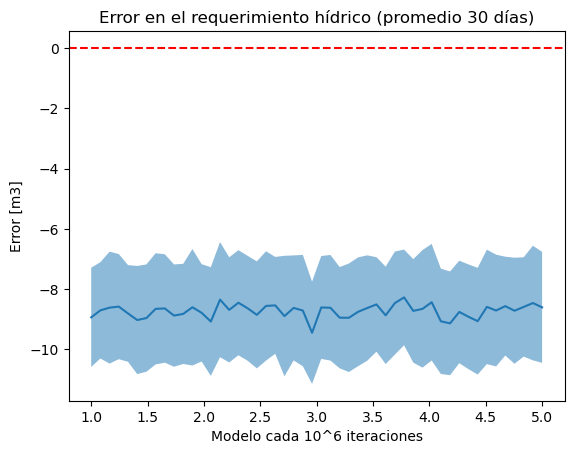

In [13]:
n = np.linspace(1,5, 50)
plt.plot(n, results[0, :])
plt.fill_between(n, results[0, :] - results[1, :], results[0, :] + results[1, :], alpha=0.5)
plt.axhline(y=0, linestyle='--', color='red')
plt.title("Error en el requerimiento hídrico (promedio 30 días)")
plt.xlabel("Modelo cada 10^6 iteraciones")
plt.ylabel("Error [m3]")
plt.savefig("error.png", dpi = 300)

In [12]:
len(file_paths), len(np.linspace(1,5, 50))

(50, 50)

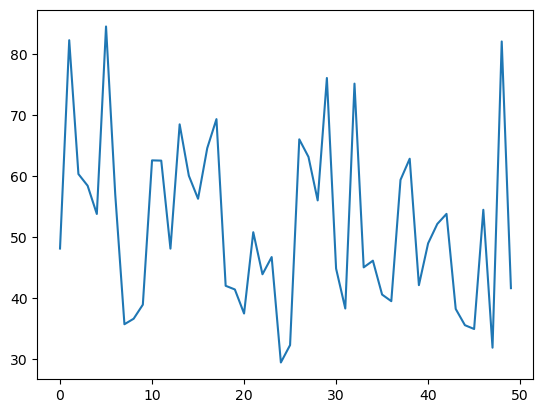

In [14]:
plt.plot(-results[2, :])

In [83]:
policy_dict = torch.load(file_paths[40], map_location=device)
policy = Actor(state_dim, action_dim, 256, max_action).to(device)
policy.load_state_dict(policy_dict)

def true_policy(state):
    if type(state) is np.ndarray:
        state = state.flatten()
        state = torch.tensor(state, dtype=torch.float32).to(device)
    return policy(state) #.cpu().data.numpy().flatten()
    

env = ContinousEMSEnv()
env.show_sample(true_policy)
fig = env.get_figure()
fig.savefig("sample.png")